In [1]:
%load_ext autoreload
%autoreload 2

fig_num = 4 # change this to the figure number
analysis_name = "hpc_plotting" # change this to the subfolder it should save to

subject = "Wallie"
date = "20220912"
nwb_file_name = f"{subject}{date}_.nwb"
epoch_interval = "10_lineartrack"
key = {"nwb_file_name": nwb_file_name,}

from spyglass.common import PositionIntervalMap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pos_interval = (PositionIntervalMap() &{**key, "interval_list_name": epoch_interval}).fetch1("position_interval_name")

/home/sambray/.local/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82
[2026-08-31 08:59:20,521][INFO]: DataJoint 0.14.9 connected to sambray@lmf-db.cin.ucsf.edu:3306


In [2]:
from spyglass.decoding.v1.c3po import Model

# model_key = {**key, "model_name":"wallie_linear_dim20_noSmooth_v0"}

model_key = {
    **key,
    # 'model_name': 'wallie_linear_dim20_10Smooth_v0',
    "model_name":"wallie_linear_dim20_noSmooth_v0",
    # "training_params_name":"wallie_20_dim_v0",
    "marks_group_name":"10_lineartrack_wf_norm1000"
    # "model_name":"wallie_dim20_HYBRID_10Smooth_v0",
}

Model & model_key
model_key = (Model & model_key).fetch1("KEY")

analysis = (Model & model_key).fetch_c3po_analysis(checkpoint = None)
analysis.fit_context_pca()
t_interp = np.arange(analysis.t[0], analysis.t[-1], 0.001)
analysis.interpolate_context(t_interp)
analysis.embed_context_pca()

from c3po.analysis.analysis import figure_directory
from pathlib import Path
fig_dir = Path(figure_directory) / f"Fig{fig_num}/{analysis_name}"/f"{subject}_{date}_{epoch_interval}"
fig_dir = fig_dir / f"{model_key['marks_group_name']}"
fig_dir = fig_dir / f"{model_key['model_name']}"
fig_dir = fig_dir / model_key["training_params_name"]
fig_dir.mkdir(parents=True, exist_ok=True)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/sambray/.local/lib/python3.10/site-packages/traitlets/

x shape (1, 5)


2026-08-31 08:59:50.497124: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-08-31 08:59:52.241493: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceM

In [8]:
# W = analysis.params["params"]["embedding"]["encoder"]["sorted_encoder"]["encoder_matrix"]
# W = W @ analysis.pca.components_.T

# plt.scatter(W[:,5], W[:,3])

# Load data

### position

In [3]:
from utils.load_hpc_data import load_position_data

pos_data = load_position_data(nwb_file_name, epoch_interval)

pos_df = pos_data["pos_df"]
pos_times = pos_data["pos_times"]
pos = pos_data["pos"]
vel = pos_data["vel"]
all_running_intervals = pos_data["all_running_intervals"]
left_running_intervals = pos_data["left_running_intervals"]
right_running_intervals = pos_data["right_running_intervals"]


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Devic

### LFP

In [4]:
from utils.load_hpc_data import load_lfp_data

lfp_data = load_lfp_data(nwb_file_name, epoch_interval)
theta_phase_df = lfp_data["theta_phase_df"]
fg_phase_df = lfp_data["fg_phase_df"]
sg_phase_df = lfp_data["sg_phase_df"]


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Devic

### SortedData

In [5]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

spikes_key = {
    **key,
    "sorted_spikes_group_name": epoch_interval,
}
SortedSpikesGroup() & spikes_key
spikes_list, unit_ids = (SortedSpikesGroup() & spikes_key).fetch_spike_data(
    spikes_key, return_unit_ids=True
)

[09:00:49][WARNING] Spyglass: Missing code for CurationV2
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-pa

### Ripples

In [6]:
from spyglass.ripple.v1 import RippleTimesV1, RippleLFPSelection

ripple_df = (
    RippleTimesV1()
    & key
    & f"target_interval_list_name LIKE '%{pos_interval}%'"
).fetch1_dataframe()
ripple_intervals = ripple_df[["start_time", "end_time"]].values

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Devic

### DIO Behavior Marks

In [7]:
from spyglass.common import DIOEvents

event_types = ["poke", "reward"]
behavior_events = {}
for dio in event_types:
    dio_query = DIOEvents() & key & f"dio_event_name LIKE '%{dio}%'"
    marks = []
    for nwb in dio_query.fetch_nwb():
        obj = nwb["dio"]
        t = obj.timestamps[:]
        data = obj.data[:]
        marks.extend(t[data == 1])
    marks = np.array(marks)
    marks = marks[np.logical_and(marks >= pos_times[0], marks <= pos_times[-1])]
    behavior_events[dio] = marks

[2026-08-31 09:01:47,940][WARNING]: Skipped checksum for file with hash: bbc80993-55d4-5fc6-0ca9-d62eecdb0f15, and path: /stelmo/nwb/raw/Wallie20220912_.nwb
[2026-08-31 09:01:47,961][WARNING]: Skipped checksum for file with hash: bbc80993-55d4-5fc6-0ca9-d62eecdb0f15, and path: /stelmo/nwb/raw/Wallie20220912_.nwb
[2026-08-31 09:01:47,978][WARNING]: Skipped checksum for file with hash: bbc80993-55d4-5fc6-0ca9-d62eecdb0f15, and path: /stelmo/nwb/raw/Wallie20220912_.nwb
[2026-08-31 09:01:47,995][WARNING]: Skipped checksum for file with hash: bbc80993-55d4-5fc6-0ca9-d62eecdb0f15, and path: /stelmo/nwb/raw/Wallie20220912_.nwb
[2026-08-31 09:01:48,016][WARNING]: Skipped checksum for file with hash: bbc80993-55d4-5fc6-0ca9-d62eecdb0f15, and path: /stelmo/nwb/raw/Wallie20220912_.nwb
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines Excitat

# Analyze

In [9]:
# analysis.fit_context_pca(fit_intervals=all_running_intervals)
analysis.fit_context_pca()
analysis.embed_context_pca()

## Example Plot

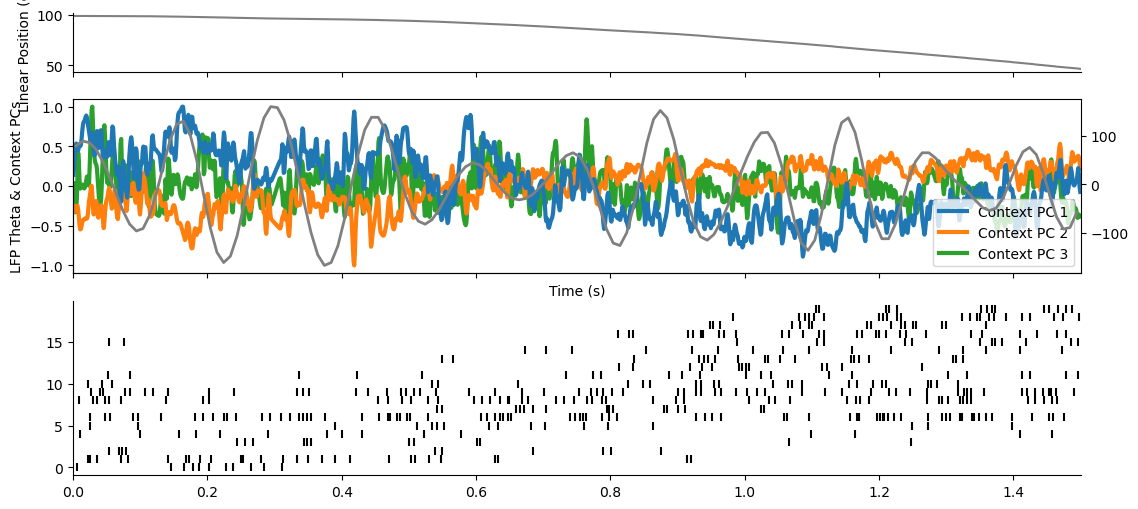

In [10]:
# analysis = analysis_all
from scipy.ndimage import gaussian_filter1d
i = 30
# t_rng = 2,5
# t_rng = 2.5, 3.5

# i = 5
# t_rng = -1, 2
# t_rng = 1.6, 2.6
# t_rng = 3, 6
# t_rng = 3.5, 5

i = 5
t_rng = -1, 2
t_rng = 1.6, 2.6
t_rng = 3, 6
t_rng = 3.5, 5

smooth_width = 1

pc_inds = np.array([0, 1])
pc_inds = np.array([0,1, 2,])
# t_rng = 3,4

fig, ax = plt.subplots(
    nrows=3,
    sharex=True,
    height_ratios=[1, 3, 3],
    figsize=(13, 6),
)

# ax = ax_list[1:]

interval = [i_ for i_ in left_running_intervals if i_[1] - i_[0] > 0.5]
interval = interval[i]
st = left_running_intervals[i][0] + t_rng[0]
en = left_running_intervals[i][0] + t_rng[1]

t_theta = theta_phase_df.index
ind_theta = np.logical_and(
    t_theta >= st,
    t_theta <= en,
)
theta_ax = ax[1].twinx()
theta_ax.plot(
    t_theta[ind_theta] - st,
    theta_phase_df["signal"].values[ind_theta],
    c="grey",
    lw=2,
    zorder=-10,
    label="LFP Theta Band",
)

ind_context = np.logical_and(
    analysis.t_interp >= st,
    analysis.t_interp <= en,
)
c_plot = analysis.c_pca_interp[ind_context][:, pc_inds]
if len(c_plot.shape) == 1:
    c_plot = c_plot[:, None]

c_plot = gaussian_filter1d(c_plot, smooth_width, axis=0, mode="nearest")
c_plot = c_plot - np.mean(c_plot, axis=0)
c_plot = c_plot / (np.max(np.abs(c_plot), axis=0))
for j in range(len(pc_inds)):
    ax[1].plot(
        analysis.t_interp[ind_context] - st,
        c_plot[:, j],
        zorder=1 - j,
        label=f"Context PC {j+1}",
        lw=3,
    )
    # break


pos_ind = np.logical_and(
    pos_df.index >= st,
    pos_df.index <= en,
)
ax[0].plot(
    pos_df.index[pos_ind] - st,
    pos_df.linear_position[pos_ind],
    c="gray",
    # s=5,
    zorder=-5,
)
# plt.xlim(4,5)
# plt.xlim(2,3)
# ind_theta = np.logical_and(
#     phase_df.index >= left_running_intervals[i][0], phase_df.index <= left_running_intervals[i][0] +dur,
# )
# plt.plot(phase_df.index[ind_theta], phase_df["electrode 12"].values[ind_theta])

ind_theta = np.logical_and(
    theta_phase_df.index >= st,
    theta_phase_df.index <= en,
)
# plt.plot(
#     phase_df.index[ind_theta] - st,
#     phase_df["phase"].values[ind_theta],
# )

ax[1].legend(loc="lower right")
for a in ax:
    a.spines[["top", "right"]].set_visible(False)

ax[1].set_xlabel("Time (s)")
ax[0].set_ylabel("Linear Position (cm)")
ax[1].set_ylabel("LFP Theta & Context PCs")
plt.xlim(0, t_rng[1] - t_rng[0])


min_spikes = 10
plot_spikes = []
for s in spikes_list:
    s_st = np.digitize(st, s)
    s_en = np.digitize(en, s)
    if s_en - s_st < min_spikes:
        continue
    plot_spikes.append(s[s_st:s_en])

order = np.argsort([np.mean(s) for s in plot_spikes])
plot_spikes = [plot_spikes[i] for i in order]
for i, s in enumerate(plot_spikes):
    ax[2].scatter(s - st, np.ones(len(s)) * i, marker="|", color="k")

## Bin and plot by position

In [85]:
pos_bins = np.linspace(10, 110, 50)
pca = True
analysis_ = analysis#_running

left_binned_context, bins = analysis_.bin_context_by_feature(
    pos_df.linear_position.values,
    pos_df.index,
    pca=pca,
    valid_intervals=left_running_intervals,
    bins=pos_bins,
    # interpolated=True,
)

right_binned_context, bins = analysis_.bin_context_by_feature(
    pos_df.linear_position.values,
    pos_df.index,
    pca=pca,
    valid_intervals=right_running_intervals,
    bins=pos_bins,
    # interpolated=True,
)

mid_list = []
lo_list = []
hi_list = []

for j, binned_context in enumerate([left_binned_context, right_binned_context]):
    mid = np.array([np.nanmedian(b, axis=0) for b in binned_context])
    hi = np.array(
        [
            np.nanpercentile(
                b,
                75,
                axis=0,
            )
            for b in binned_context
        ]
    )
    lo = np.array(
        [
            np.nanpercentile(
                b,
                25,
                axis=0,
            )
            for b in binned_context
        ]
    )
    mid_list.append(mid)
    lo_list.append(lo)
    hi_list.append(hi)

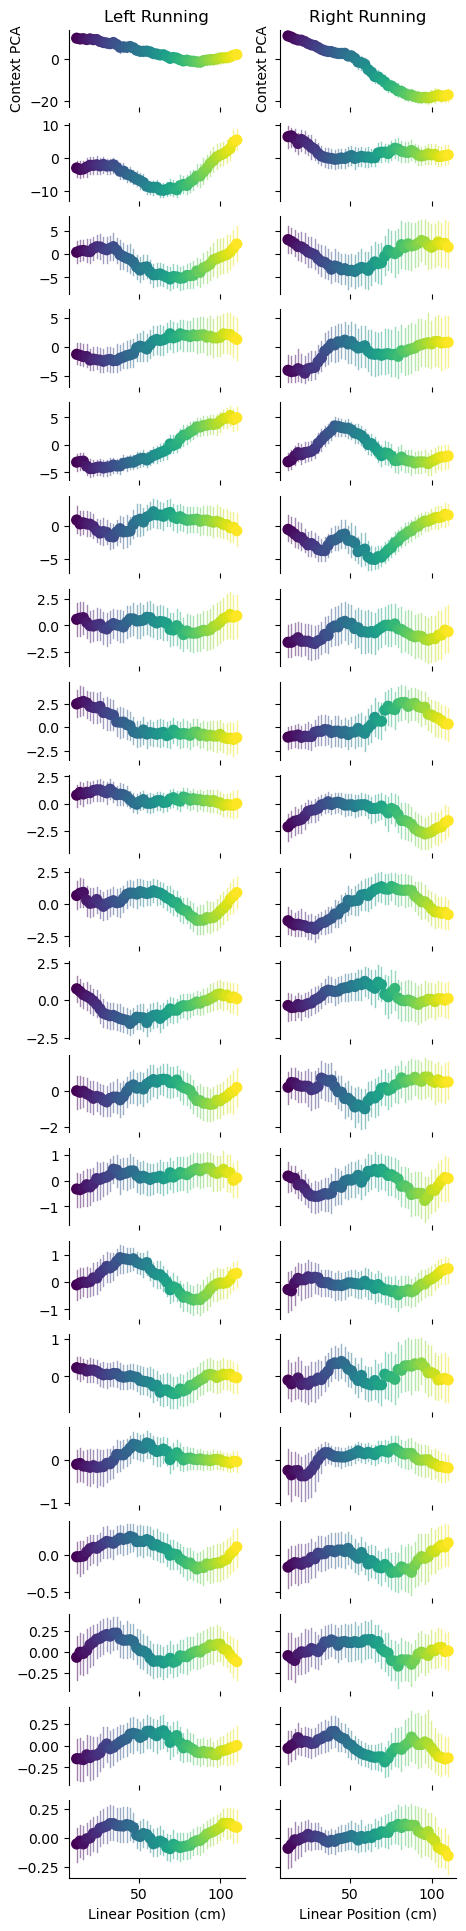

In [86]:
n_plot = 20
n_plot = min(analysis.context_dim, n_plot)

fig, ax_list = plt.subplots(
    nrows=n_plot, ncols=2, sharex=True, sharey="row", figsize=(5, 1.2 * n_plot)
)
for j, name in enumerate(["Left", "Right"]):
    ax = ax_list[:, j]
    mid = mid_list[j]
    lo = lo_list[j]
    hi = hi_list[j]
    c = np.linspace(0, 1, mid.shape[0])
    for i, a in enumerate(ax):
        a.scatter(bins[1:], mid[:, i], s=50, c=c)
        # a.vlines(bins[1:], lo[:, i], hi[:, i], alpha=0.5, zorder=-1)
        for k in range(len(bins[1:])):
            a.plot(
                [bins[k + 1], bins[k + 1]],
                [lo[k, i], hi[k, i]],
                alpha=0.5,
                zorder=-1,
                c=plt.cm.viridis(c[k]),
                lw=1,
            )
        a.spines[["top", "right", "bottom"]].set_visible(False)
    ax[-1].spines["bottom"].set_visible(True)

    ax[-1].set_xlabel("Linear Position (cm)")
    ax[0].set_title(f"{name} Running")
    ax[0].set_ylabel("Context PCA")

In [18]:
mid_list[0].shape

(49, 20)

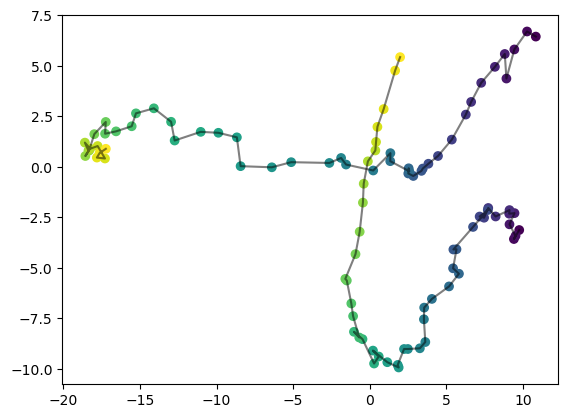

In [87]:
pc_to_plot = (0,1)
fig = plt.figure
for j, name in enumerate(["Left", "Right"]):
    mid = mid_list[j]
    plt.scatter(mid[:, pc_to_plot[0]], mid[:, pc_to_plot[1]], c=np.linspace(0, 1, mid.shape[0]), label=name)
    plt.plot(mid[:, pc_to_plot[0]], mid[:, pc_to_plot[1]], c="k", alpha=0.5)

## Aligned response

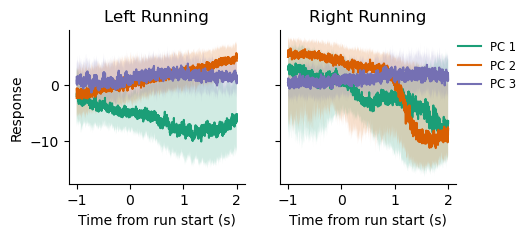

In [11]:
window = (-1,2)
fig, ax = plt.subplots(ncols=2, sharex=True,sharey=True, figsize=(5, 2))


for i, (direction, intervals, a) in enumerate(
    zip(["Left", "Right"], [left_running_intervals, right_running_intervals,], ax)
):
    marks = intervals[:, 0]
    response = analysis.alligned_response(marks,t_plot = window)
    mid = np.nanmedian(response, axis=0)
    lo = np.nanpercentile(response, 25, axis=0)
    hi = np.nanpercentile(response, 75, axis=0)

    t_plot = np.linspace(window[0], window[1], mid.shape[0])
    for j in range(3):
        color = plt.cm.Dark2(j/8)
        a.plot(t_plot, mid[:, j], label=f"PC {j+1}", color=color)
        a.fill_between(t_plot, lo[:, j], hi[:, j], alpha=0.2, facecolor=color)


    a.set_title(f"{direction} Running")
    a.set_xlabel("Time from run start (s)")
    a.spines[["top", "right"]].set_visible(False)
ax[0].set_ylabel("Response")

ax[1].legend(loc="upper right",bbox_to_anchor=(1.4, 1), fontsize="small",frameon=False)



## Precession

In [52]:
n_pos = 100
n_theta = 50

n_pos = 40
n_theta = 15

# n_pos = 150
# n_theta = 75

left_binned_context, b1, b2, counts_left = analysis.bin_context_by_feature_2d(
    pos_df.linear_position.values,
    pos_df.index,
    theta_phase_df.phase.values,
    theta_phase_df.index,
    pca=True,
    interpolated=True,
    valid_intervals=left_running_intervals,
    bins_1=np.linspace(10, 110, n_pos),
    bins_2=np.linspace(0+.01, 2 * np.pi - 0.01, n_theta),
    return_counts=True,
)


right_binned_context, b1, b2, counts_right = analysis.bin_context_by_feature_2d(
    pos_df.linear_position.values,
    pos_df.index,
    theta_phase_df.phase.values,
    theta_phase_df.index,
    pca=True,
    interpolated=True,
    valid_intervals=right_running_intervals,
    bins_1=np.linspace(10, 110, n_pos),
    bins_2=np.linspace(0, 2 * np.pi - 0.01, n_theta),
    return_counts=True,
)

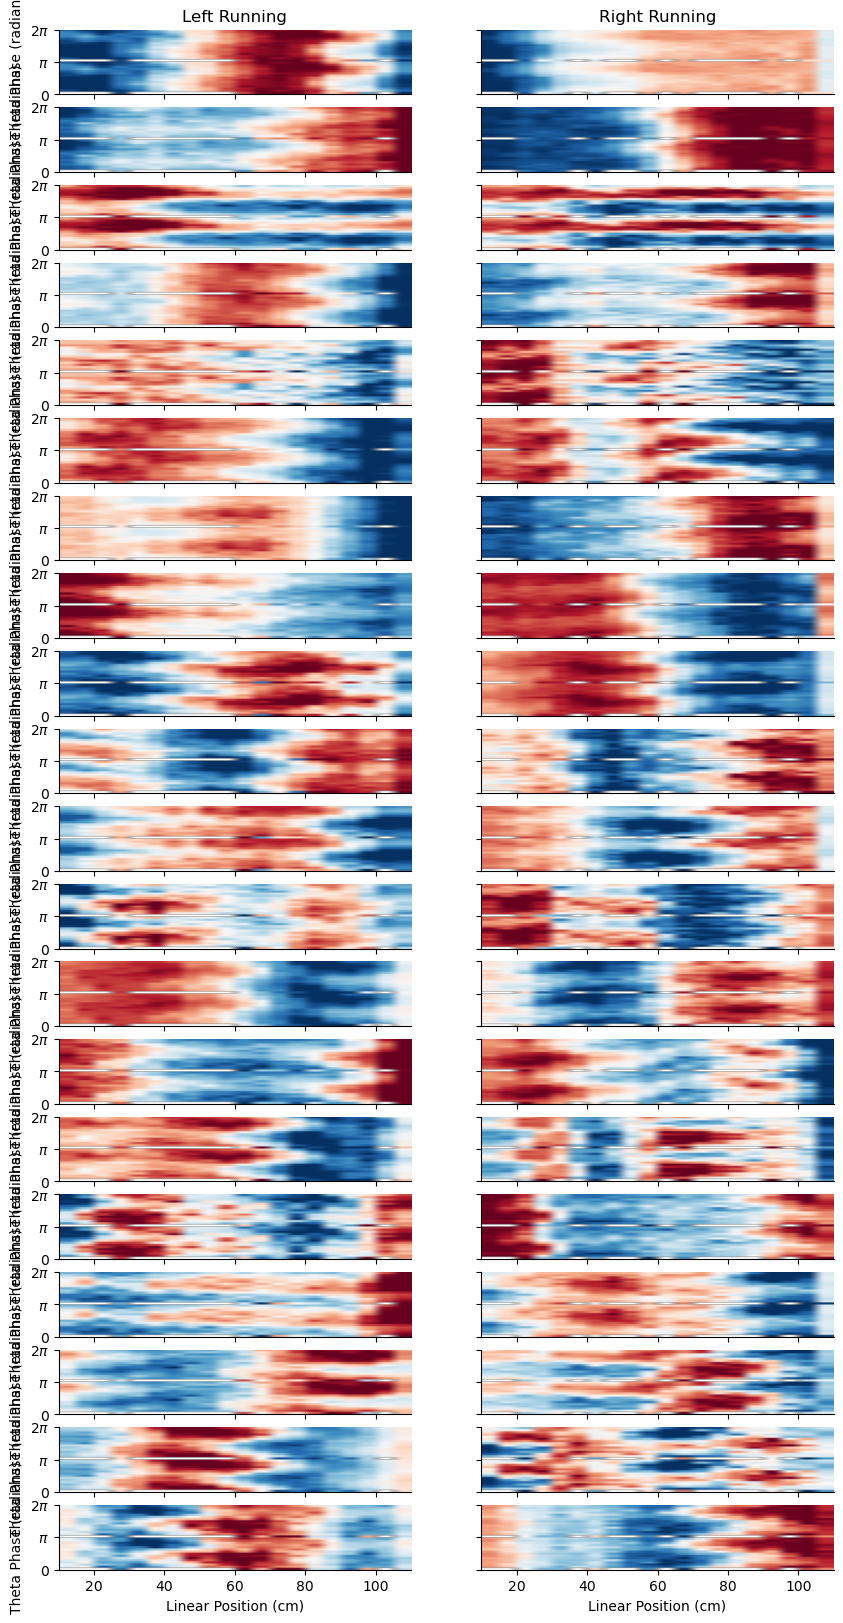

In [29]:
n_plot = 20

mid_left = np.array(
    [
        [
            np.nanmean(b, axis=0) if len(b) else np.nan * np.zeros(analysis.context_dim)
            for b in row
        ]
        for row in left_binned_context
    ]
)
mid_right = np.array(
    [
        [
            np.nanmean(b, axis=0) if len(b) else np.nan * np.zeros(analysis.context_dim)
            for b in row
        ]
        for row in right_binned_context
    ]
)
mid.shape
fig, ax_list = plt.subplots(
    nrows=min(analysis.context_dim, n_plot),
    sharex=True,
    sharey=True,
    figsize=(10, n_plot * 1),
    ncols=2,
)


for j, (name, data) in enumerate(zip(["Left", "Right"], [mid_left, mid_right])):
    ax = ax_list[:, j]
    ax[0].set_title(f"{name} Running")
    for i, a in enumerate(ax):
        val = data[:, :, i].T
        val = val - np.nanmean(val)
        val = val / np.nanpercentile(np.abs(val), 97)
        # val = np.roll(val, val.shape[0] // 2, axis=0)
        val = np.concatenate(
            [
                val,
                val,
            ],
            axis=0,
        )
        a.imshow(
            val,
            cmap="RdBu",
            extent=[b1[0], b1[-1], b2[0], b2[-1]],
            aspect="auto",
            clim=(-0.9, 0.9),
        )
        a.spines[
            [
                "top",
                "right",
            ]
        ].set_visible(False)

for a in ax_list[-1]:
    a.spines["bottom"].set_visible(True)
    a.set_xlabel("Linear Position (cm)")
for a in ax_list[:, 0]:
    a.set_ylabel("Theta Phase (radians)")
    # a.set_yticks(
    #     np.linspace(0, 2 * np.pi, 3),
    #     [r"-$\pi$", "0", r"$\pi$"],
    # )
    a.set_yticks(
        np.linspace(0, 2 * np.pi, 3),
        ["0", r"$\pi$", r"$2\pi$"],
    )

# plt.imshow(mid[:,:,1].T,cmap='RdBu',extent=[b1[0],b1[-1],b2[0],b2[-1]],aspect='auto')
# plt.colorbar()

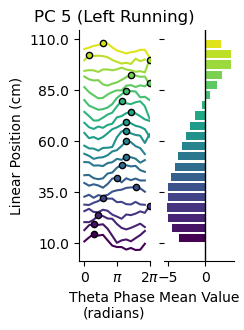

In [ ]:
pc = 5
data = mid_left

# fig = plt.figure(figsize=(2, 5))

# fig, ax = plt.subplots(figsize=(3, 5), ncols=2, width_ratios=[2, 1], sharey=True)
fig, ax = plt.subplots(figsize=(2, 3), ncols=2, width_ratios=[1, 1], sharey=True)

val = data[:, :, pc].T

scale_factor = 0
for i in range(val.shape[-1]):
    val_i = val[:, i].copy()
    mid_i = np.nanmean(val_i)
    val_i = val_i - np.nanmean(val_i)
    scale_i = np.nanpercentile(np.abs(val_i), 97)
    if scale_i > scale_factor:
        scale_factor = scale_i


for i in range(val.shape[-1]):
    val_i = val[:, i].copy()
    mid_i = np.nanmean(val_i)

    val_i = val_i - np.nanmean(val_i)
    val_i = val_i / scale_factor
    # val_i = val_i / np.nanpercentile(np.abs(val_i), 97)
    # val_i = val_i / np.nanpercentile(np.abs(val), 97) *3
    c = plt.cm.viridis(i / val.shape[-1])
    ax[0].plot(b2[:], val_i + i * 1, c=c)
    ind_max = np.nanargmax(val[:, i])
    ind_min = np.nanargmin(val[:, i])
    ind_mark = ind_max
    ax[0].scatter(b2[ind_mark], val_i[ind_mark] + i * 1,
                  facecolor=c,edgecolor="k", s=20, zorder=50)

    ax[1].barh(i + 0.5, mid_i, color=plt.cm.viridis(i / val.shape[-1]))
    # ind_min = np.nanargmin(val[:, i])
    # plt.scatter(b2[ind_min], val_i[ind_min] + i * 1, c='r', s=100, zorder=50)

ax[0].set_xticks(
    np.linspace(0, 2 * np.pi, 3),
    ["0", r"$\pi$", r"$2\pi$"],
)
ax[0].set_yticks(
    np.linspace(0, val.shape[-1] * 1, 5),
    np.linspace(b1[0], b1[-1], 5),
)
ax[0].set_xlabel("Theta Phase \n(radians)")
ax[0].set_ylabel("Linear Position (cm)")
ax[0].set_title(f"PC {pc} (Left Running)")

for a in ax:
    a.spines[["top", "right"]].set_visible(False)
ax[0].set_xlim(-0.5, 2 * np.pi)


ax[1].spines["left"].set_visible(False)
ax[1].axvline(0, c="k", ls="-", lw=1)
# ax[1].set_xticks(
#     [-2, 0, 2],
# )
ax[1].set_xlabel("Mean Value")

fig.savefig(
    fig_dir / f"contextPCA_thetaPhase_position_PC{pc}_leftRunning.svg",
)

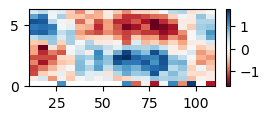

In [58]:
fig = plt.figure(figsize=(3,1))
mid_plot = mid_left[:, :, pc].T
mid_plot = mid_plot - np.nanmean(mid_plot, axis=0, keepdims=True)
plt.imshow(mid_plot, cmap="RdBu", extent=[b1[0], b1[-1], b2[0], b2[-1]], aspect="auto",)# clim = (-5,5))
plt.colorbar()

In [35]:
import sortingview.views as vv
import os
from matplotlib.colors import to_hex

os.environ["KACHERY_API_KEY"] = "g9UmADRrAGfSPs1RRNKd6DtYTao3WQd2"


color_list = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]

subsample = 3
context_graph = vv.TimeseriesGraph()

c_fig = analysis.c_pca
# c_fig = smooth(c_fig, sigma=int(10), hamming=True)
c_fig = c_fig[::subsample]
t_fig = analysis.t[::subsample]

# c_fig = analysis.c_pca_interp[::subsample]
# t_fig = analysis.t_interp[::subsample]

ind = ~np.any(np.isnan(c_fig), axis=1)
c_fig = c_fig[ind]
t_fig = t_fig[ind]


for i in np.arange(
    3,
):
    context_graph.add_line_series(
        name=f"context pc: {i}",
        t=t_fig,
        y=c_fig[:, i].astype(np.float32),
        width=2,
        color=color_list[i],
    )


context_graph2 = vv.TimeseriesGraph()
for i in np.arange(3, 7):
    context_graph2.add_line_series(
        name=f"context pc: {i}",
        t=t_fig,
        y=c_fig[:, i].astype(np.float32),
        width=2,
        color=color_list[i],
    )


# Speed graph
speed_graph = vv.TimeseriesGraph()
# for angle in trials_df.reach_angle.unique():
#     angle_df = trials_df[trials_df.reach_angle == angle]
#     print(angle_df.size)
#     color = to_hex(plt.cm.hsv((angle + np.pi) / (2 * np.pi)))
#     intervals_ = angle_df.target_on_time.values
#     # intervals_ = [[i, i+.5] for i in intervals_]
#     speed_graph.add_interval_series(
#         name=f"{angle} cue",
#         t_start=intervals_,
#         t_end=intervals_ + 0.05,
#         color=color,
#     )

#     intervals_ = angle_df.go_cue_time.values
#     # intervals_ = [[i, i+.5] for i in intervals_]
#     speed_graph.add_interval_series(
#         name=f"{angle} go",
#         t_start=intervals_,
#         t_end=intervals_ + 1,
#         color=color,
#     )

speed_graph.add_line_series(
    name="lin_pos",
    t=pos_df.index.values,
    y=pos_df.linear_position.values.astype(np.float32),
    color=color_list[0],
    width=2,
)
# speed_graph.add_line_series(
#     name="vel_y",
#     t=behavior_df.index.values,
#     y=behavior_df.hand_vel_y.values.astype(np.float32),
#     color=color_list[1],
#     width=2,
# )

# mua_graph = vv.TimeseriesGraph()
# mua_graph.add_line_series(
#     name="mua",
#     t=pos_df.index.values,
#     y=mua.astype(np.float32),
#     color=color_list[2],
#     width=2,
# )


# ASSEMBLE
context_panels = [
    vv.LayoutItem(speed_graph, stretch=1),

    # vv.LayoutItem(lfp_graph, stretch=1),
    # vv.LayoutItem(mua_graph, stretch=1),
    vv.LayoutItem(context_graph, stretch=3),
    vv.LayoutItem(context_graph2, stretch=3),
]

view = vv.Box(
    direction="horizontal",
    show_titles=True,
    height=8,
    items=[
        vv.LayoutItem(
            vv.Box(
                direction="vertical",
                show_titles=True,
                items=context_panels,
            )
        ),
    ],
)
view.url(label=f"wallie_linear_smooth_training2")

'https://figurl.org/f?v=npm://@fi-sci/figurl-sortingview@12/dist&d=kachery:franklab.default:sha1:c6946981ebb20e09b431998f5e56501fe2fe7f73&label=wallie_linear_smooth_training2&zone=franklab.default'

In [36]:
# from spyglass.decoding.v1.c3po import MarksGroup
# MarksGroup() & "norm_method LIKE 'by_const%'"
# (Model & (MarksGroup & "norm_method LIKE 'by_const%'")).delete()

[2026-07-13 09:01:33,660][INFO]: Deleting 2 rows from `decoding_c3po_v1`.`__model`
[2026-07-13 09:01:38,326][INFO]: Delete committed.


In [55]:
window = (-1, 3)
results_left = analysis.alligned_response(
    left_running_intervals[:,0],
    t_plot = window,
    pca=True
)
results_left.shape

results_right = analysis.alligned_response(
    right_running_intervals[:,0],
    t_plot = window,
    pca=True
)
results_left.shape

(136, 4000, 20)

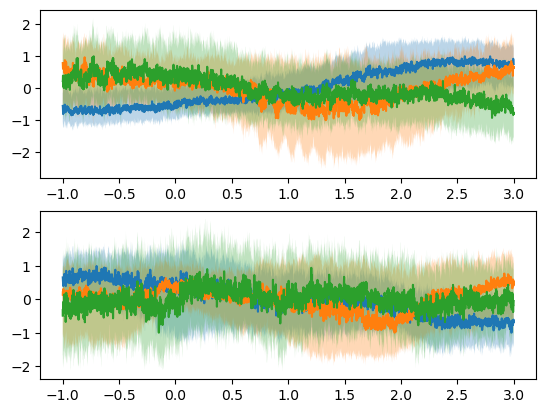

In [ ]:
fig, ax = plt.subplots(
    nrows=2
)
mid = np.median(results_left, axis=0)
lo = np.percentile(results_left, 25, axis=0)
hi = np.percentile(results_left, 75, axis=0)

center = np.mean(mid, axis=0)
mid = mid - center
sc = np.max(np.abs(mid), axis=0)
mid = mid / sc
lo = lo - center
hi = hi - center
lo = lo / sc
hi = hi / sc

t_plot = np.linspace(window[0], window[1], results_left.shape[1])
for i in range(3):
    ax[0].plot(t_plot, mid[:, i])
    ax[0].fill_between(t_plot, lo[:, i], hi[:, i], alpha=0.3)

mid = np.median(results_right, axis=0)
lo = np.percentile(results_right, 25, axis=0)
hi = np.percentile(results_right, 75, axis=0)

center = np.mean(mid, axis=0)
mid = mid - center
sc = np.max(np.abs(mid), axis=0)
mid = mid / sc
lo = lo - center
hi = hi - center
lo = lo / sc
hi = hi / sc

t_plot = np.linspace(window[0], window[1], results_right.shape[1])
for i in range(3):
    ax[1].plot(t_plot, mid[:, i])
    ax[1].fill_between(t_plot, lo[:, i], hi[:, i], alpha=0.3)